# Roubo e furto de veículos no Rio de Janeiro: o que mudou entre 2023 e 2025

Nos últimos anos o Rio de Janeiro tem sido notícia constante quando o assunto é segurança pública, e um dos temas que mais aparece nas conversas do dia a dia é o roubo e o furto de veículos. Mas será que os números oficiais confirmam essa percepção?

Esta análise usa os dados abertos do Instituto de Segurança Pública do Rio de Janeiro (ISP-RJ) para comparar o comportamento de roubo e furto de veículos entre 2023, 2024 e 2025, mês a mês. A ideia é sair da impressão do dia a dia e ver o que os registros oficiais realmente mostram.

**Fonte dos dados:** [ISPDados](http://www.ispdados.rj.gov.br/) — série histórica mensal do estado do Rio de Janeiro desde 1991.

## 1. Importando as bibliotecas e carregando os dados

O primeiro passo é trazer os dados direto da fonte oficial. Como é um arquivo de um portal do governo brasileiro, é comum precisar ajustar o separador de colunas e a codificação de texto, então já entramos com esses parâmetros configurados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "http://www.ispdados.rj.gov.br/Arquivos/DOMensalEstadoDesde1991.csv"
df = pd.read_csv(url, sep=';', encoding='latin1')

df.head()

,ano,mes,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,feminicidio,letalidade_violenta,tentat_hom,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1991,1,657,NaN,15,NaN,NaN,NaN,672,162,...,NaN,NaN,NaN,NaN,217,NaN,NaN,NaN,NaN,3
1,1991,2,732,NaN,17,NaN,NaN,NaN,749,175,...,NaN,NaN,NaN,NaN,209,NaN,NaN,NaN,NaN,3
2,1991,3,713,NaN,25,NaN,NaN,NaN,738,216,...,NaN,NaN,NaN,NaN,188,NaN,NaN,NaN,NaN,3
3,1991,4,634,NaN,20,NaN,NaN,NaN,654,200,...,NaN,NaN,NaN,NaN,140,NaN,NaN,NaN,NaN,3
4,1991,5,650,NaN,20,NaN,NaN,NaN,670,146,...,NaN,NaN,NaN,NaN,78,NaN,NaN,NaN,NaN,3


## 2. Conhecendo a base

Antes de qualquer análise, vale entender o tamanho e a estrutura dos dados: quantas colunas existem, quais são elas e se os tipos de dado vieram corretos.

In [2]:
print("Formato do dataset:", df.shape)
df.dtypes.head(10)

Formato do dataset: (427, 58)


,0
ano,int64
mes,int64
hom_doloso,int64
lesao_corp_morte,float64
latrocinio,int64
cvli,float64
hom_por_interv_policial,float64
feminicidio,float64
letalidade_violenta,int64
tentat_hom,int64


A base traz dezenas de tipos de ocorrência registrados mês a mês desde 1991. Para esta análise, o interesse está nas colunas relacionadas a roubo e furto.

In [3]:
colunas_roubo_furto = [col for col in df.columns if 'roubo' in col.lower() or 'furto' in col.lower()]
colunas_roubo_furto

['roubo_transeunte',
 'roubo_celular',
 'roubo_em_coletivo',
 'roubo_rua',
 'roubo_veiculo',
 'roubo_carga',
 'roubo_comercio',
 'roubo_residencia',
 'roubo_banco',
 'roubo_cx_eletronico',
 'roubo_conducao_saque',
 'roubo_apos_saque',
 'roubo_bicicleta',
 'outros_roubos',
 'total_roubos',
 'furto_veiculos',
 'furto_transeunte',
 'furto_coletivo',
 'furto_celular',
 'furto_bicicleta',
 'outros_furtos',
 'total_furtos']

## 3. Filtrando o período de interesse (2023 a 2025)

O objetivo aqui é comparar os três últimos anos completos disponíveis na base.

In [5]:
df_recente = df[df['ano'].isin([2023, 2024, 2025])]

print(df_recente['ano'].unique())
print(df_recente.shape)

[2023 2024 2025]
(36, 58)


São 36 linhas, o equivalente a 12 meses em cada um dos três anos, o que confirma que 2025 já está completo na base até dezembro.

Para deixar a análise mais enxuta, seguimos apenas com as colunas relevantes: ano, mês, roubo e furto de veículo, além dos totais gerais de roubo e furto no estado.


In [7]:
colunas_interesse = ['ano', 'mes', 'roubo_veiculo', 'furto_veiculos', 'total_roubos', 'total_furtos']
df_analise = df_recente[colunas_interesse]

df_analise.head()

,ano,mes,roubo_veiculo,furto_veiculos,total_roubos,total_furtos
384,2023,1,1813,1409,8047,14313
385,2023,2,1578,1297,7128,14405
386,2023,3,2309,1648,8726,14150
387,2023,4,2237,1445,7855,12557
388,2023,5,2380,1451,8530,13818


Um último cuidado antes de seguir para a análise: verificar se existe algum dado faltando nesse recorte.

In [8]:
df_analise.isnull().sum()

,0
ano,0
mes,0
roubo_veiculo,0
furto_veiculos,0
total_roubos,0
total_furtos,0


Nenhum valor ausente. Os dados estão prontos para a comparação.

## 4. Comparando os totais anuais

O primeiro olhar é simples: somar os 12 meses de cada ano e ver o total de ocorrências.

In [10]:
resumo_anual = df_analise.groupby('ano')[['roubo_veiculo', 'furto_veiculos', 'total_roubos', 'total_furtos']].sum()
resumo_anual

,roubo_veiculo,furto_veiculos,total_roubos,total_furtos
ano,,,,
2023,22248,16577,91398,166643
2024,30930,17337,106919,179529
2025,25235,17490,98459,187984


Já dá para notar um padrão diferente entre os dois tipos de crime: roubo de veículo e o total de roubos subiram de 2023 para 2024, mas caíram de 2024 para 2025. Já furto de veículo e o total de furtos cresceram nos três anos seguidos, sem interrupção.

Para colocar isso em números exatos, calculamos a variação percentual de um ano para o outro.

In [11]:
variacao = resumo_anual.pct_change() * 100
variacao.round(1)

,roubo_veiculo,furto_veiculos,total_roubos,total_furtos
ano,,,,
2023,NaN,NaN,NaN,NaN
2024,39.0,4.6,17.0,7.7
2025,-18.4,0.9,-7.9,4.7


Roubo de veículo teve uma trajetória de sobe e desce: alta de 39% em 2024 e queda de 18,4% em 2025. Furto de veículo, por outro lado, segue crescendo de forma mais discreta e constante, com alta de 4,6% em 2024 e 0,9% em 2025.

À primeira vista, parece que roubo de veículo está em queda e furto em alta lenta. Mas olhar só o total anual esconde o que aconteceu mês a mês, e é aí que a história fica mais interessante.

## 5. Olhando mês a mês: a queda de roubo não é o que parece

O total anual de 2025 caiu, mas isso não significa que a queda foi constante o ano inteiro. Para entender melhor, comparamos o comportamento mensal de roubo e furto de veículo nos três anos, lado a lado.

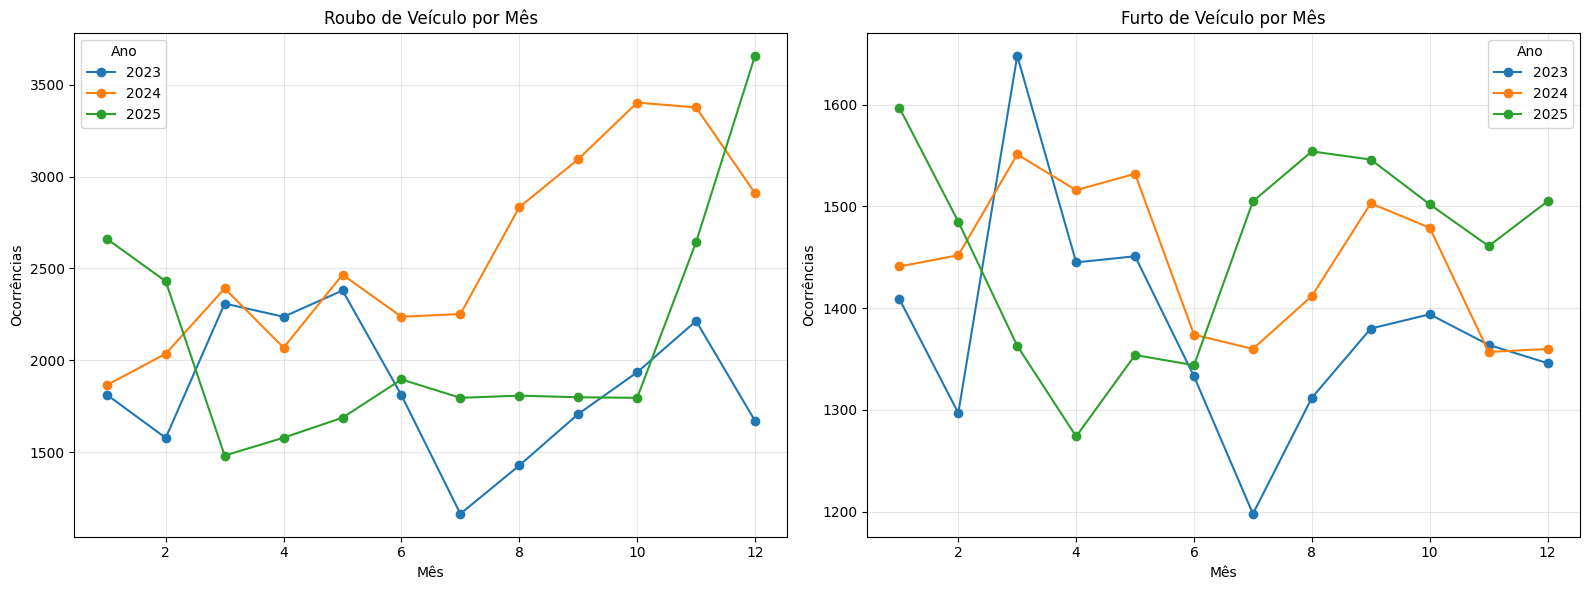

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ano in [2023, 2024, 2025]:
    dados_ano = df_analise[df_analise['ano'] == ano]
    axes[0].plot(dados_ano['mes'], dados_ano['roubo_veiculo'], marker='o', label=str(ano))
    axes[1].plot(dados_ano['mes'], dados_ano['furto_veiculos'], marker='o', label=str(ano))

axes[0].set_title('Roubo de Veículo por Mês')
axes[1].set_title('Furto de Veículo por Mês')

for ax in axes:
    ax.set_xlabel('Mês')
    ax.set_ylabel('Ocorrências')
    ax.legend(title='Ano')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

O gráfico da esquerda mostra que 2025 (linha verde) começou o ano relativamente alto, caiu e ficou estável em um patamar baixo entre março e outubro, bem abaixo de 2024 no mesmo período. Até aí, a queda de 18,4% no total anual faz sentido. O detalhe é o que acontece em novembro e dezembro: os números disparam e fecham o ano no ponto mais alto dos três anos analisados, quase 3.700 ocorrências em dezembro.

Ou seja, a queda anual de roubo de veículo em 2025 não conta a história toda. Boa parte do ano teve números baixos, mas os dois últimos meses reverteram essa tendência de forma abrupta, o que pode indicar o início de uma nova alta que só vai se confirmar (ou não) em 2026.

Já o gráfico de furto de veículo, à direita, mostra um comportamento diferente: bastante oscilação de mês a mês, sem um padrão sazonal fixo se repetindo nos três anos, mas sem essa reversão brusca de tendência que aparece no roubo. O crescimento constante fica mais visível no total anual do que no gráfico mensal.

## 6. Conclusões

Comparando os dados oficiais do ISP-RJ entre 2023 e 2025, roubo e furto de veículos seguiram caminhos bem diferentes no Rio de Janeiro.

Roubo de veículo teve uma trajetória de montanha-russa: alta de 39% em 2024, seguida de queda de 18,4% no acumulado de 2025. Só que essa queda anual esconde uma reversão importante: os números ficaram baixos e estáveis entre março e outubro, mas dispararam em novembro e dezembro, terminando o ano no patamar mais alto do período analisado.

Furto de veículo teve um comportamento mais estável no total anual, com crescimento constante nos três anos, mesmo com bastante variação mês a mês dentro de cada ano.

Duas ressalvas importantes para quem for interpretar esses números. Primeiro, os dados refletem Registros de Ocorrência, que dependem da vítima efetivamente registrar o boletim, então parte da criminalidade real pode não estar capturada nessas estatísticas. Segundo, variações também podem refletir mudanças na política de policiamento e não necessariamente na criminalidade em si.